Import + Constants

In [6]:
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from ase.io import read
from mace.calculators import mace_mp

EV_TO_HARTREE = 1.0 / 27.211386245988
EH_TO_KJMOL = 2625.5

User Parameters (for Editing)

In [7]:
INPUT_FOLDER = Path("inc")  # <-- set to folder named exactly "inc" or "ser"

DEVICE = "cpu"          # "cpu" or "cuda"
DTYPE = "float64"
HEAD = "spice_wB97M"

os.makedirs("csv", exist_ok=True)
os.makedirs("heatmap", exist_ok=True)


mode = INPUT_FOLDER.name.lower()
if mode not in {"inc", "ser"}:
    raise ValueError(f"Input folder name must be 'inc' or 'ser', got: {INPUT_FOLDER.name}")

ABS_CSV_PATH      = f"csv/energies_absolute_{mode}.csv"
REL_GRID_CSV_PATH = f"csv/energies_relative_{mode}.csv"
HEATMAP_PATH      = f"heatmap/heatmap_{mode}.png"


Helpers

In [8]:
def parse_z_L_from_stem(stem: str):
    mz = re.search(r"_z(\d+)", stem)
    mL = re.search(r"_L(\d+)", stem)
    if not (mz and mL):
        return np.nan, np.nan
    z = float(mz.group(1)) / 10.0
    L = float(mL.group(1)) / 10.0
    return z, L

Single-point MACE energies for all CIFs -> absolute CSV (Hartree)

In [9]:
cif_files = sorted(INPUT_FOLDER.glob("*.cif"))  # only directly inside inc/ser
if not cif_files:
    raise FileNotFoundError(f"No .cif files found in: {INPUT_FOLDER.resolve()}")

calc = mace_mp(default_dtype=DTYPE, device=DEVICE, head=HEAD)

rows = []
failed = []

for i, cif_path in enumerate(cif_files, start=1):
    try:
        atoms = read(str(cif_path))
        atoms.calc = calc

        e_ev = float(atoms.get_potential_energy())
        e_eh = e_ev * EV_TO_HARTREE

        z, L = parse_z_L_from_stem(cif_path.stem)

        rows.append({
            "structure": cif_path.stem,
            "mode": mode,
            "z": z,
            "L": L,
            "energy_Eh": e_eh,
        })

    except Exception as e:
        failed.append((str(cif_path), repr(e)))

    if i % 25 == 0 or i == len(cif_files):
        print(f"[single-point] {i}/{len(cif_files)} done | ok={len(rows)} | failed={len(failed)}")

df = pd.DataFrame(rows).sort_values("structure").reset_index(drop=True)
df.to_csv(ABS_CSV_PATH, index=False)

if failed:
    print("\nFailed files (first 10):")
    for p, err in failed[:10]:
        print(" -", p)
        print("   ", err)
    print("Total failed:", len(failed))

df.head()

Using medium MPA-0 model as default MACE-MP model, to use previous (before 3.10) default model please specify 'medium' as model argument
Using Materials Project MACE for MACECalculator with /Users/gregorlauter/.cache/mace/macempa0mediummodel
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Using head spice_wB97M out of ['default']


/Users/gregorlauter/tools/anaconda3/envs/mace/lib/python3.10/site-packages/mace/calculators/mace.py:197: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(f=model_pat

[single-point] 25/144 done | ok=25 | failed=0
[single-point] 50/144 done | ok=50 | failed=0
[single-point] 75/144 done | ok=75 | failed=0
[single-point] 100/144 done | ok=100 | failed=0
[single-point] 125/144 done | ok=125 | failed=0
[single-point] 144/144 done | ok=144 | failed=0


,structure,mode,z,L,energy_Eh
0,COF-1_z30_inc_L000,inc,3.0,0.0,-10.852896
1,COF-1_z30_inc_L010,inc,3.0,1.0,-10.879066
2,COF-1_z30_inc_L020,inc,3.0,2.0,-10.910162
3,COF-1_z30_inc_L030,inc,3.0,3.0,-10.929239
4,COF-1_z30_inc_L040,inc,3.0,4.0,-10.939945


Heatmap

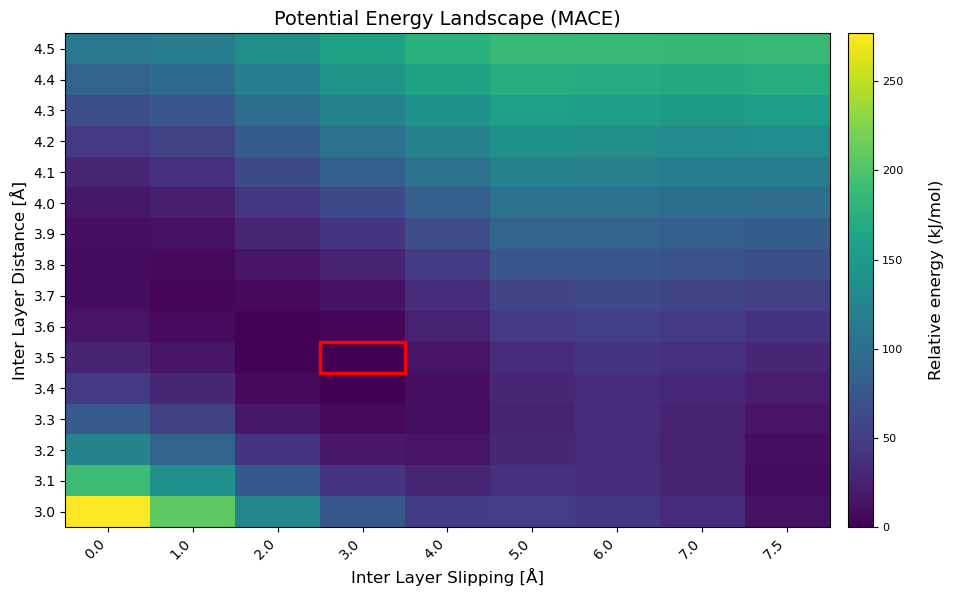

Saved: heatmap/heatmap_inc.png


In [10]:
# Only keep entries where z/L parsing worked
df2 = df.dropna(subset=["z", "L", "energy_Eh"]).copy()
if df2.empty:
    raise ValueError("No entries with parsed z/L. Check naming like ..._z30_..._L020.cif")

# Pivot to wide (z rows, L columns)
abs_grid = df2.pivot_table(index="z", columns="L", values="energy_Eh", aggfunc="last").sort_index()

# Relative (kJ/mol) w.r.t. global min
if abs_grid.empty:
    print("No matching folders or no energies parsed. Check INPUT_FOLDER and filename naming.")
else:
    if mode.lower() == "ser":
        first_col = abs_grid.columns[0]
        print(f"Mode = 'ser' → multiplying column {first_col} by 2")
        abs_grid[first_col] = abs_grid[first_col] * 2

    vals = np.array(abs_grid.values, dtype=float)
    mask = np.isfinite(vals)
    if not mask.any():
        raise ValueError("Grid has no finite energies (unexpected).")

    global_min = vals[mask].min()
    rel_grid = (abs_grid - global_min) * EH_TO_KJMOL

# Save relative grid CSV (as requested)
rel_grid.to_csv(REL_GRID_CSV_PATH, index=True)

# --- Plot heatmap like your original ---
plt.figure(figsize=(10, 6))
data = rel_grid.values

im = plt.imshow(data, aspect="auto", origin="lower")
cbar = plt.colorbar(im, pad=0.02)
cbar.set_label("Relative energy (kJ/mol)", labelpad=18, fontsize = 12)

plt.xticks(range(len(rel_grid.columns)), [f"{c:.1f}" for c in rel_grid.columns], rotation=45, ha="right", fontsize = 10)
plt.yticks(range(len(rel_grid.index)), [f"{r:.1f}" for r in rel_grid.index], fontsize = 10)

plt.xlabel("Inter Layer Slipping [Å]", fontsize = 12)
plt.ylabel("Inter Layer Distance [Å]", fontsize = 12)
plt.title("Potential Energy Landscape (MACE)", fontsize = 14)

# Highlight minimum with a red square
finite_vals = np.array(data, dtype=float)
min_pos = np.unravel_index(np.nanargmin(finite_vals), finite_vals.shape)
y, x = min_pos
rect = patches.Rectangle(
    (x - 0.5, y - 0.5),
    1, 1,
    linewidth=2.5,
    edgecolor="red",
    facecolor="none",
)
plt.gca().add_patch(rect)

plt.tight_layout()
plt.savefig(HEATMAP_PATH, dpi=200)
plt.show()

print(f"Saved: {HEATMAP_PATH}")